# DDoS Data Analysis: Visualization, Feature Engineering & ML Plan

Ez a notebook tartalmazza az adatok vizualizációját, az új feature-k előállítását, adatdúsítást

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

## Adatvizualizáció

In [5]:
# Adathalmazok betöltése (SetA)
events_df = pd.read_csv('ddos-data-2024/SCLDDoS2024_SetA_events.csv')
components_df = pd.read_csv('ddos-data-2024/SCLDDoS2024_SetA_components.csv')

# Dátum oszlopok konvertálása (hibás vagy '0' értékek kezelése 'coerce' kapcsolóval)
events_df['Start time'] = pd.to_datetime(events_df['Start time'], errors='coerce')
events_df['End time'] = pd.to_datetime(events_df['End time'], errors='coerce')
components_df['Time'] = pd.to_datetime(components_df['Time'], errors='coerce')

### A. Osztályeloszlás (Class Distribution)
Látni fogjuk, hogy az adathalmaz erősen imbalanced, a normál forgalom dominál.

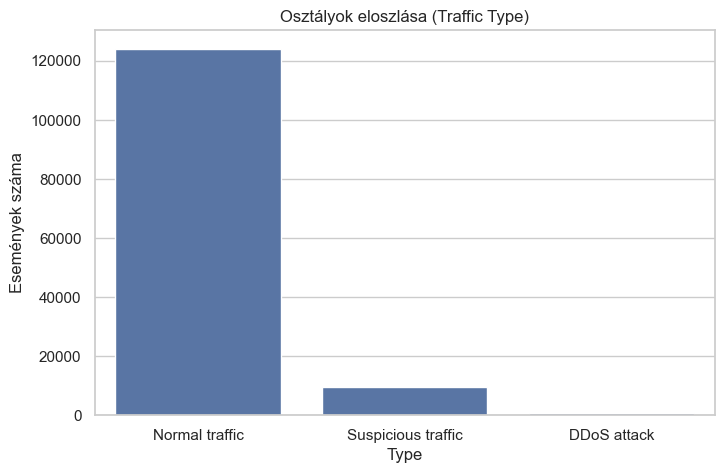

In [6]:
plt.figure(figsize=(8, 5))
sns.countplot(data=events_df, x='Type', order=events_df['Type'].value_counts().index)
plt.title('Osztályok eloszlása (Traffic Type)')
plt.ylabel('Események száma')
plt.show()

### B. Packet speed eloszlás forgalom típusonként

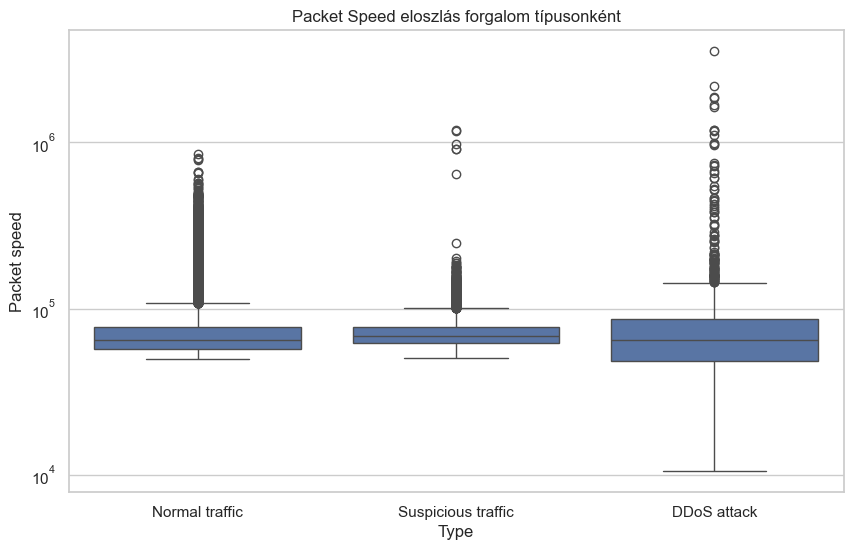

In [7]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=events_df, x='Type', y='Packet speed')
plt.title('Packet Speed eloszlás forgalom típusonként')
plt.yscale('log') # Logaritmus skála a kiugró értékek miatt
plt.show()

### C. Source IP count eloszlás
A DDoS (Distributed) definíciójából adódóan a támadások ált. magas forrásszámmal rendelkeznek.

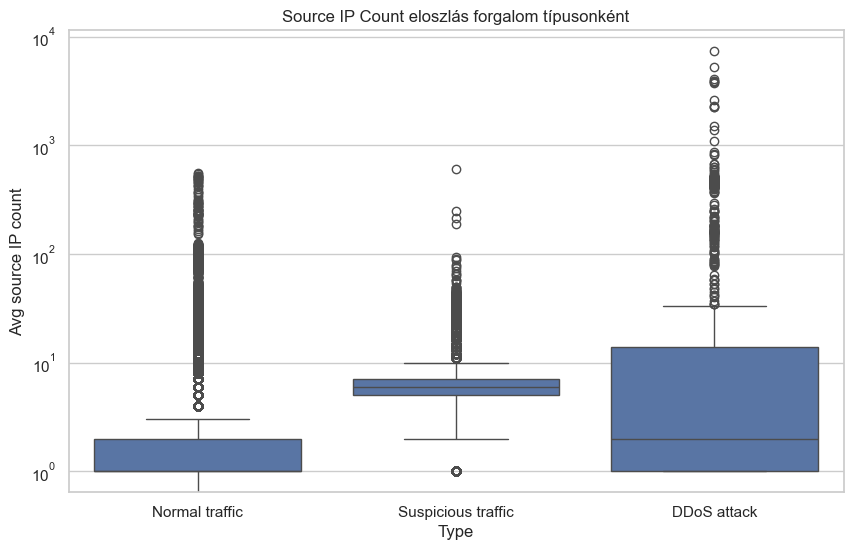

In [8]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=events_df, x='Type', y='Avg source IP count')
plt.title('Source IP Count eloszlás forgalom típusonként')
plt.yscale('log')
plt.show()

### D. Időbeli eloszlás (események / óra)

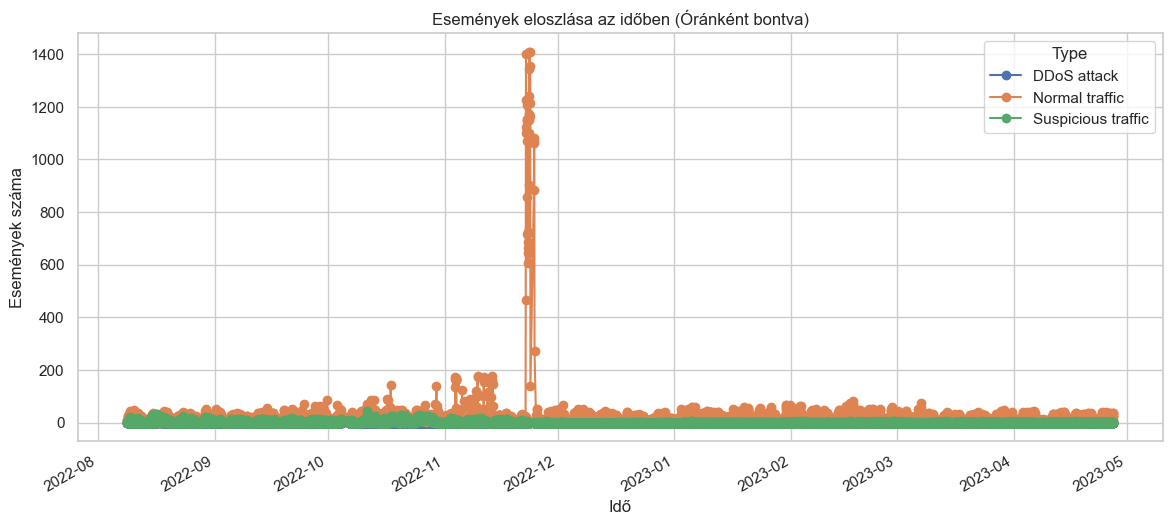

In [9]:
events_df['Hour_timestamp'] = events_df['Start time'].dt.floor('H')
time_dist = events_df.groupby(['Hour_timestamp', 'Type']).size().unstack(fill_value=0)

time_dist.plot(kind='line', figsize=(14, 6), marker='o')
plt.title('Események eloszlása az időben (Óránként bontva)')
plt.ylabel('Események száma')
plt.xlabel('Idő')
plt.show()

### E. Event duration
Meddig tartanak az egyes események átlagosan?

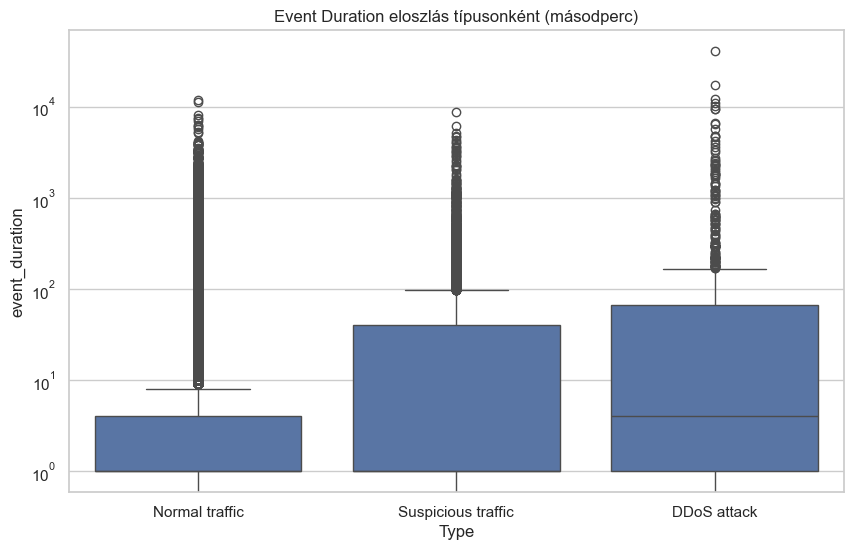

In [10]:
events_df['event_duration'] = (events_df['End time'] - events_df['Start time']).dt.total_seconds()

plt.figure(figsize=(10, 6))
sns.boxplot(data=events_df, x='Type', y='event_duration')
plt.title('Event Duration eloszlás típusonként (másodperc)')
plt.yscale('log')
plt.show()

## Feature Engineering & Adatdúsítás

Új feature-ök generálása az alábbi esetek figyelembevételével:
- **Event-level features**: Esemény időtartama, packet/data ratio
- **Adatdúsítás**: Időhöz köthető adatok (hour_of_day, is_weekend), illetve támadási intenzitás
- **Component-level features**: Aggregált statisztikák a komponensekből és növekedési ütem (growth)

In [11]:
# A. Event-level és B. Adatdúsítás (Time-based és Network behavior)
events_df['hour_of_day'] = events_df['Start time'].dt.hour
events_df['weekday'] = events_df['Start time'].dt.weekday
events_df['is_weekend'] = events_df['weekday'].apply(lambda x: 1 if x >= 5 else 0)

# Packet / Data ratio
events_df['packet_data_ratio'] = events_df['Packet speed'] / (events_df['Data speed'] + 1e-9)

# Attack Intensity (Adatdúsítás)
events_df['attack_intensity'] = events_df['Packet speed'] * events_df['Avg source IP count']

display(events_df[['Type', 'event_duration', 'hour_of_day', 'packet_data_ratio', 'attack_intensity']].head())

,Type,event_duration,hour_of_day,packet_data_ratio,attack_intensity
0,Normal traffic,1.0,18,761.643836,333600
1,Normal traffic,0.0,18,705.555556,63500
2,Normal traffic,1.0,18,764.634146,62700
3,Normal traffic,1.0,18,700.000000,59500
4,Normal traffic,56.0,18,692.477876,78250


In [12]:
# C. Component-level aggregált feature-ök kicsatolása az events_df-be
comp_agg = components_df.groupby('Attack ID').agg(
    mean_packet_speed=('Packet speed', 'mean'),
    max_packet_speed=('Packet speed', 'max'),
    std_packet_speed=('Packet speed', 'std'),
    mean_source_ip_count=('Source IP count', 'mean'),
    max_source_ip_count=('Source IP count', 'max'),
    component_count=('Attack ID', 'count'),
    first_time=('Time', 'min'),
    last_time=('Time', 'max')
).reset_index()

# Nullák kezelése std esetén
comp_agg['std_packet_speed'] = comp_agg['std_packet_speed'].fillna(0)

# Temporal dynamics: Source IP count növekedése (rate)
comp_agg['duration_comp'] = (comp_agg['last_time'] - comp_agg['first_time']).dt.total_seconds()
comp_agg['source_ip_growth_rate'] = np.where(
    comp_agg['duration_comp'] > 0, 
    comp_agg['max_source_ip_count'] / comp_agg['duration_comp'], 
    0
)

# Adatok egyesítése: Events + Components aggregáció
enriched_events = events_df.merge(comp_agg.drop(columns=['first_time', 'last_time', 'duration_comp']), on='Attack ID', how='left')

display(enriched_events[['Attack ID', 'Type', 'mean_packet_speed', 'std_packet_speed', 'source_ip_growth_rate', 'component_count']].head())

,Attack ID,Type,mean_packet_speed,std_packet_speed,source_ip_growth_rate,component_count
0,1,Normal traffic,55600.0,0.000000,0.000000,1.0
1,2,Normal traffic,63500.0,0.000000,0.000000,1.0
2,3,Normal traffic,62700.0,4242.640687,1.000000,2.0
3,4,Normal traffic,59500.0,0.000000,0.000000,1.0
4,5,Normal traffic,78250.0,4879.036790,0.017857,2.0


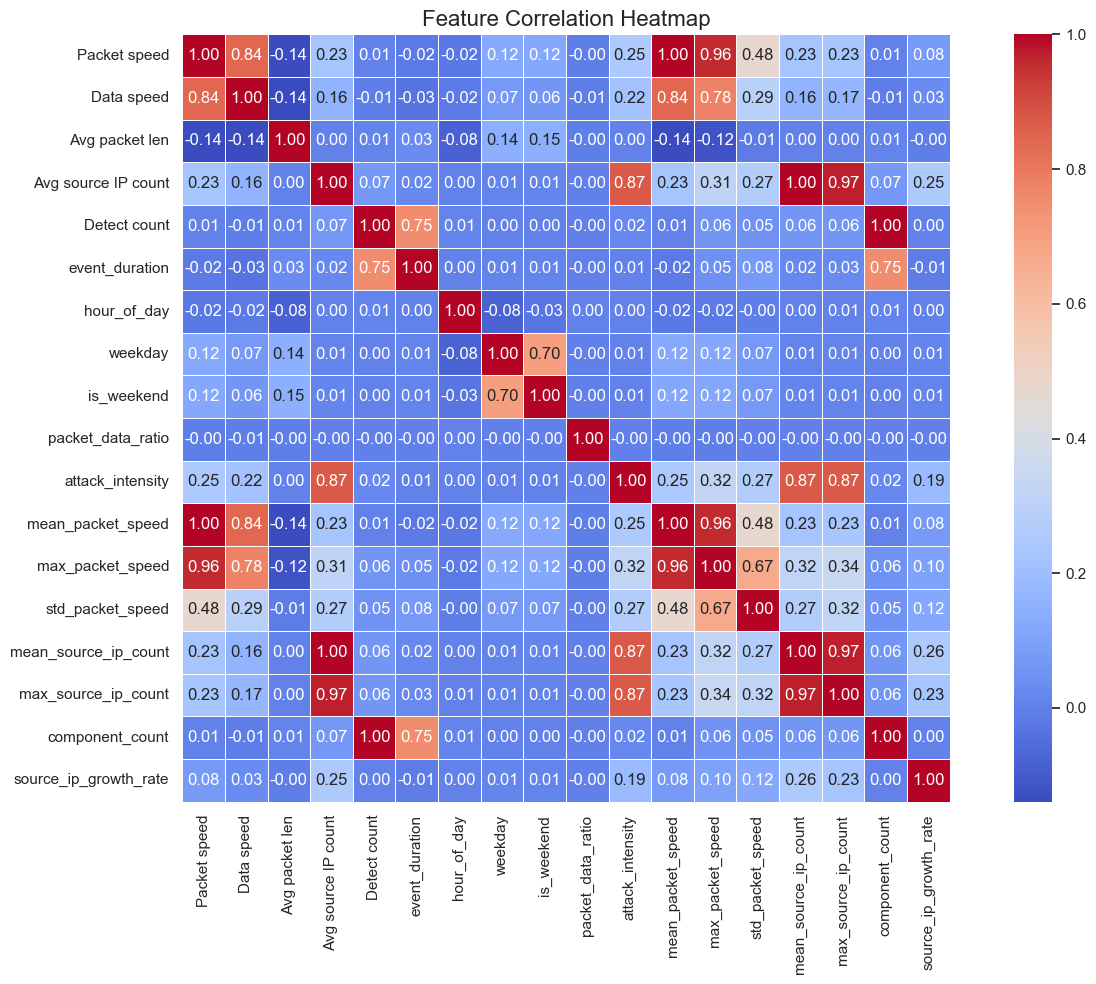

In [13]:
# D. Feature Correlation Map

# Select numerical features for correlation
numeric_features = [
    'Packet speed', 'Data speed', 'Avg packet len', 'Avg source IP count',
    'Detect count', 'event_duration', 'hour_of_day', 'weekday', 'is_weekend',
    'packet_data_ratio', 'attack_intensity', 'mean_packet_speed',
    'max_packet_speed', 'std_packet_speed', 'mean_source_ip_count',
    'max_source_ip_count', 'component_count', 'source_ip_growth_rate'
]

# Create correlation matrix
corr_matrix = enriched_events[numeric_features].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix, 
    annot=True, 
    fmt=".2f", 
    cmap="coolwarm", 
    cbar=True, 
    square=True,
    linewidths=.5
)
plt.title('Feature Correlation Heatmap', fontsize=16)
plt.tight_layout()
plt.show()